# Exercises

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import numpy as np
import sys
import os
sys.path.append(os.path.abspath("code"))
from utils import download_data
import lfp_functions as lf

# sns.set_theme(context='notebook',style='white',font_scale=1.5,
#               rc = {'axes.spines.top':False,'axes.spines.right':False,
#                      'image.cmap':plt.cm.jet})

sns.set_theme(context='notebook',style='white',font_scale=1.5,
               rc = {'axes.spines.top':False,'axes.spines.right':False})



## Exercise 1: explore filter parameters
---
In this exercises you will explore how different parameters affect the filtering process.
- Import the data form `data/moving_lfp.pickle` (the file is already on your machine if you run the `download_data()` cell in the main lesson)
- Take a few seconds of the data, and filter them in different frequency bands. Plot the resulting singal.
  Fix the central frequency and play with the width of the band, then try to change the central frequency of the band.
- Change the order of the filter, keeping the frequency band fixed. How does the filtered signal change? How does the computing time change? (You can try to quantify the computing time with the jupyter magic command [`%timeit`](https://docs.python.org/3/library/timeit.html) )
- Comment on what you see

Loaded 600.133 seconds of LFP, sampled at 1000.0 Hz, focusing on a slice of 2.0 seconds
Below I plot the first 2 seconds of the signal.


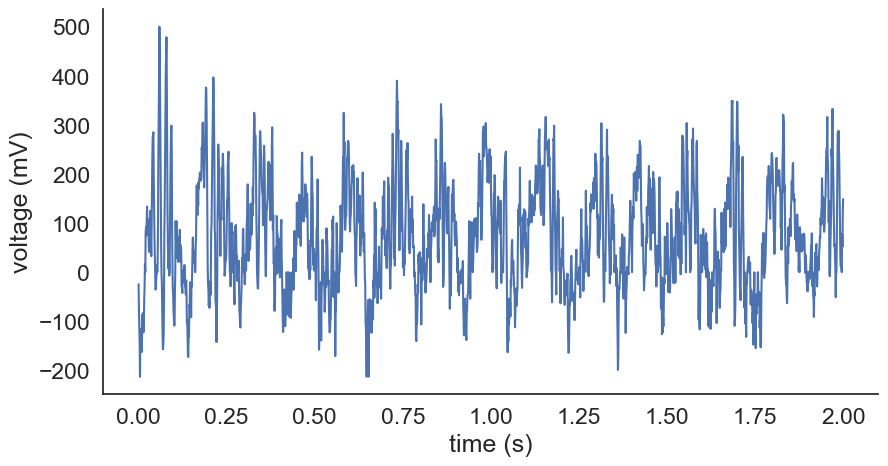

In [2]:
# Download lesson data
download_data('https://surfdrive.surf.nl/files/index.php/s/9nY01qMimFLez40')

# Loading the data in
with open('data/moving_lfp.pickle', 'rb') as handle:
    lfp_data = pickle.load(handle)

lfp = lfp_data['lfp']
sampling_rate = lfp_data['sampling_rate']
few_seconds = 2                                     # Added line to parameterize how many seconds of signal we take 
few_seconds_data = int(sampling_rate*few_seconds)   # Calculates how many data points we need based on how many seconds of the signal we want
lfp_slice = lfp_data['lfp'][:few_seconds_data]            # Redefines lfp such that lesson code can be utilized as easily as possible for the rest of the exercises

print(f'Loaded {len(lfp)/sampling_rate} seconds of LFP, sampled at {sampling_rate} Hz, focusing on a slice of {len(lfp_slice)/sampling_rate} seconds')
print(f'Below I plot the first {few_seconds} seconds of the signal.')

plt.figure(figsize=(10,5))
plt.plot(np.linspace(0,int(few_seconds),int(few_seconds*sampling_rate)),lfp_slice);  # Modified such that plotting will adapt to however many seconds of data we want to plot
plt.xlabel('time (s)');
plt.ylabel('voltage (mV)');


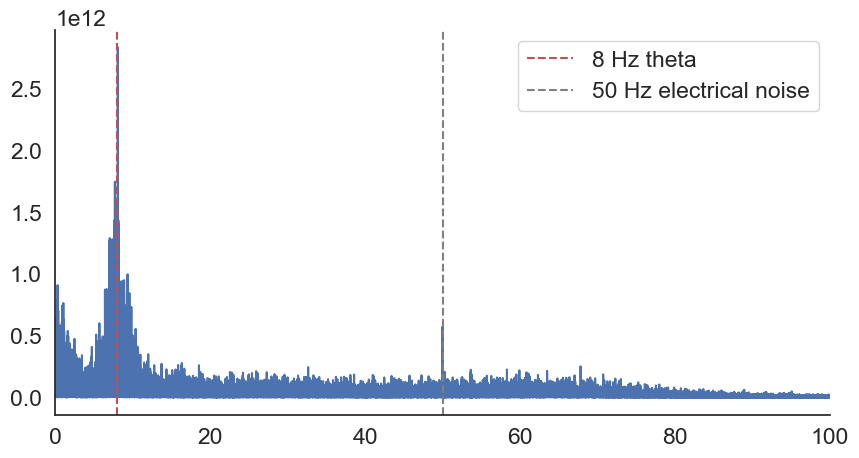

In [3]:
from scipy.fft import fft, fftfreq

n_samples = len(lfp)
sample_dt = 1. / sampling_rate

# we subtract the mean to get rid of the 0 frequency component in the spectrum
centered_lfp = lfp - np.mean(lfp)

transformed_signal = fft(centered_lfp) 

frequencies = fftfreq(n_samples,sample_dt) 

transformed_signal = transformed_signal[:n_samples//2]
frequencies = frequencies[:n_samples//2]

power = abs(transformed_signal)**2

plt.figure(figsize = (10,5))
plt.plot(frequencies,power)
plt.xlim([0,100]) # restrict to 
plt.axvline(x=8 ,c='r',linestyle='--',label='8 Hz theta')
plt.axvline(x=50 ,c='grey',linestyle='--',label='50 Hz electrical noise')

plt.legend()


Investigating the effect of bandwidth, focusing on theta band

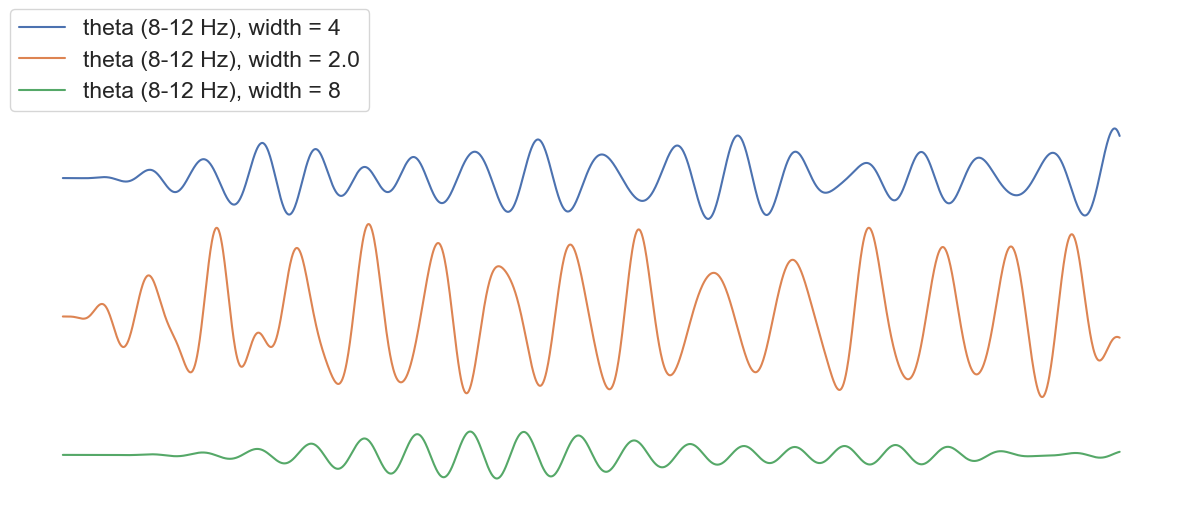

In [4]:
f_theta_central = 10 
width_theta_central = 4

theta_lfp_orig = lf.bandpass_filter(lfp,low_f=8,high_f=12, sampling_rate=sampling_rate)
theta_lfp_wider = lf.bandpass_filter(lfp, low_f = f_theta_central - width_theta_central, high_f = f_theta_central + width_theta_central, sampling_rate=sampling_rate)
theta_lfp_narrower = lf.bandpass_filter(lfp, low_f = f_theta_central - width_theta_central/4, high_f = f_theta_central + width_theta_central/4, sampling_rate=sampling_rate)

plot_offset = 200 #to plot the signal on different lines

plt.figure(figsize=(15,5))
plt.plot(theta_lfp_orig[:2000]+2*plot_offset,label= f'theta (8-12 Hz), width = {width_theta_central}')
plt.plot(theta_lfp_wider[:2000]+plot_offset,label = f'theta (8-12 Hz), width = {width_theta_central/2}')
plt.plot(theta_lfp_narrower[:2000],label = f'theta (8-12 Hz), width = {width_theta_central*2}')

plt.axis('off')
plt.legend(loc=(0,1))

now shifting the central frequency

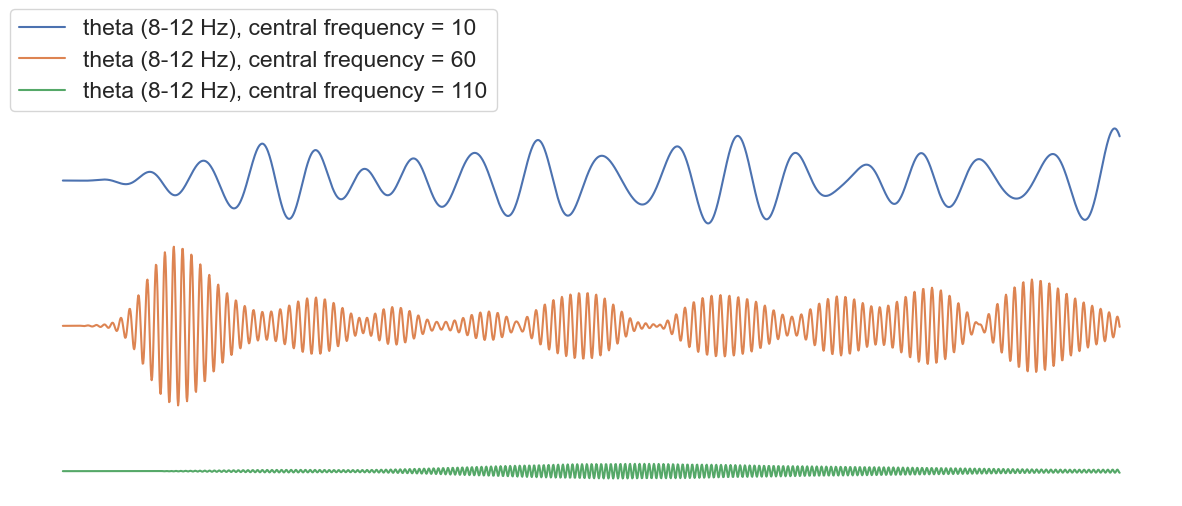

In [5]:
f_theta_central = 10 
width_theta_central = 4 # As was used originally for the theta oscillations 

theta_lfp_orig = lf.bandpass_filter(lfp, low_f = f_theta_central - width_theta_central/2, high_f = f_theta_central + width_theta_central/2, sampling_rate=sampling_rate)
theta_lfp_wider = lf.bandpass_filter(lfp, low_f = f_theta_central+50 - width_theta_central, high_f = f_theta_central+50 + width_theta_central, sampling_rate=sampling_rate)
theta_lfp_narrower = lf.bandpass_filter(lfp, low_f = f_theta_central+100 - width_theta_central/4, high_f = f_theta_central+100 + width_theta_central/4, sampling_rate=sampling_rate)

plot_offset = 200 #to plot the signal on different lines

plt.figure(figsize=(15,5))
plt.plot(theta_lfp_orig[:2000]+2*plot_offset,label= f'theta (8-12 Hz), central frequency = {f_theta_central}')
plt.plot(theta_lfp_wider[:2000]+plot_offset,label = f'theta (8-12 Hz), central frequency = {f_theta_central + 50}')
plt.plot(theta_lfp_narrower[:2000],label = f'theta (8-12 Hz), central frequency = {f_theta_central +100}')

plt.axis('off')
plt.legend(loc=(0,1))

Inspecting the effect of filter order, focusing on theta frequency band

Text(0, 0.5, 'voltage (mV)')

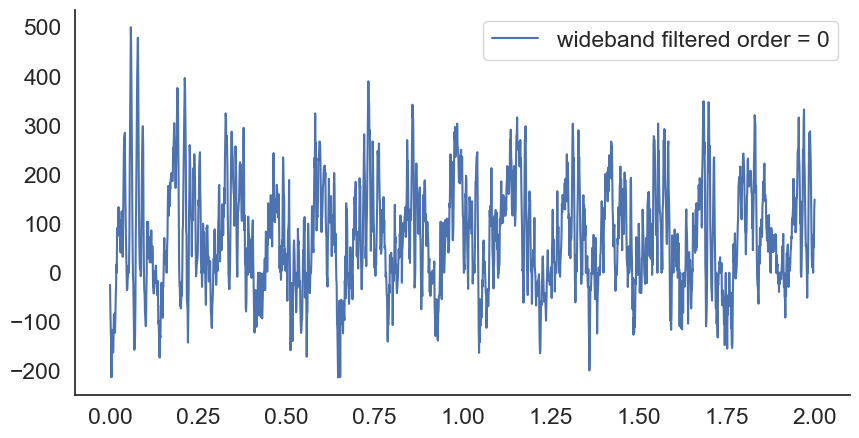

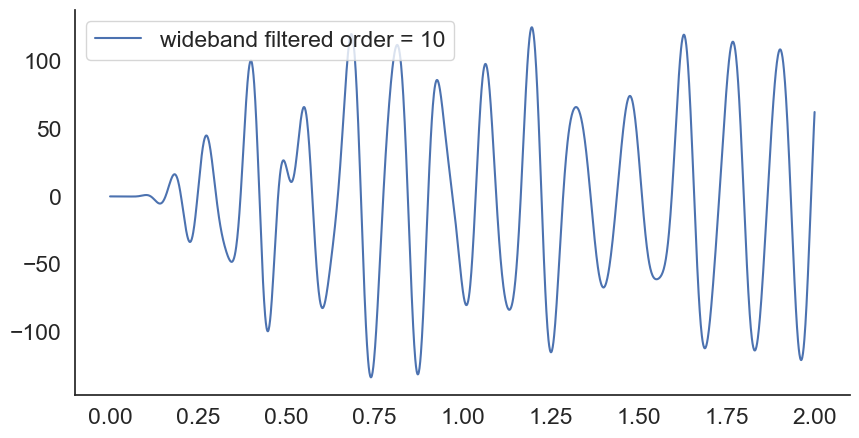

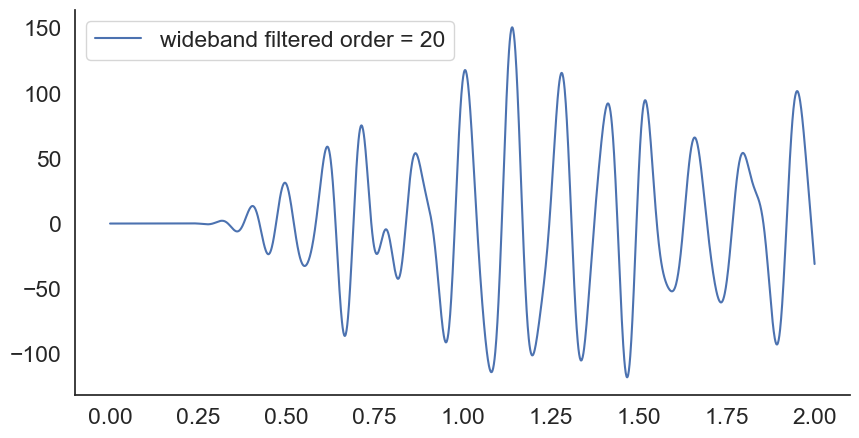

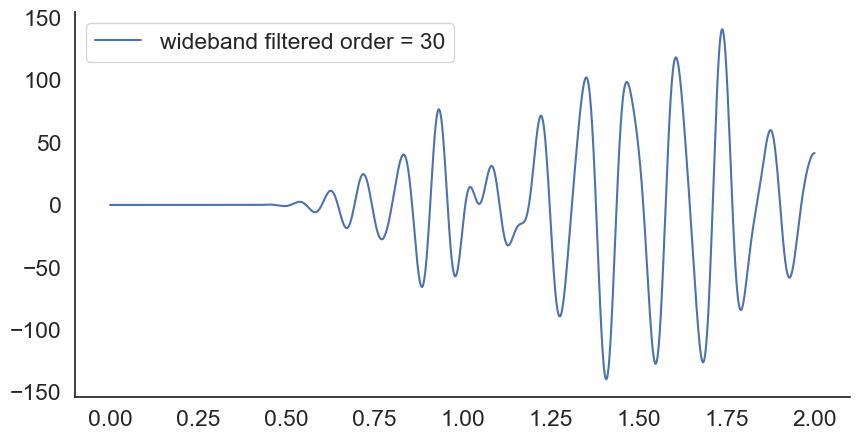

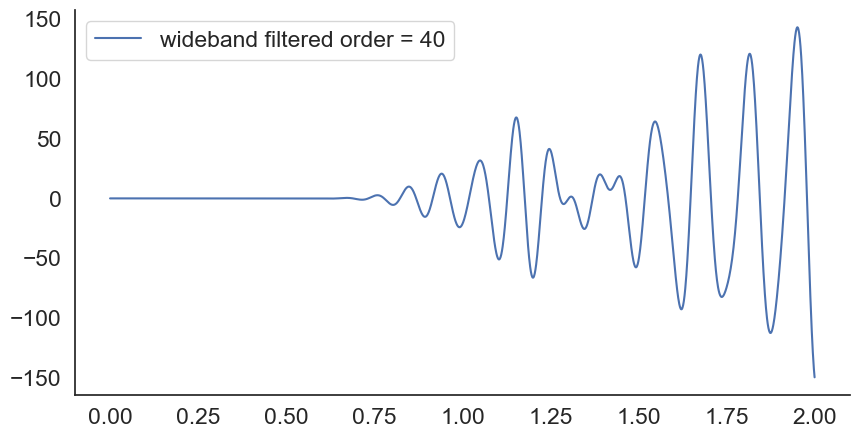

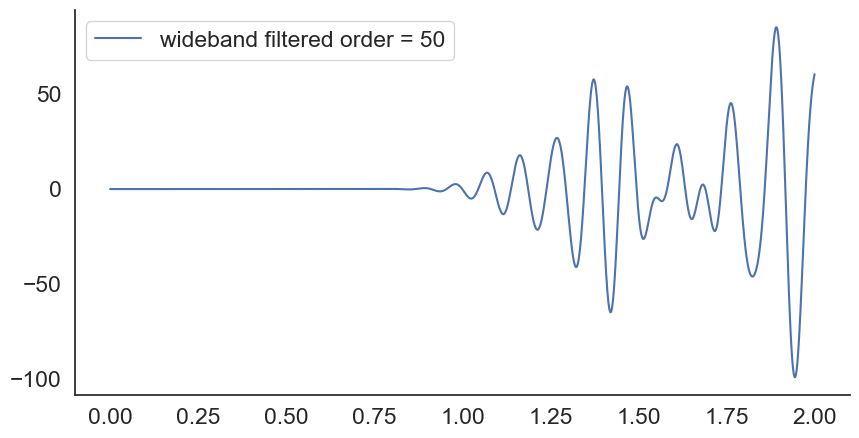

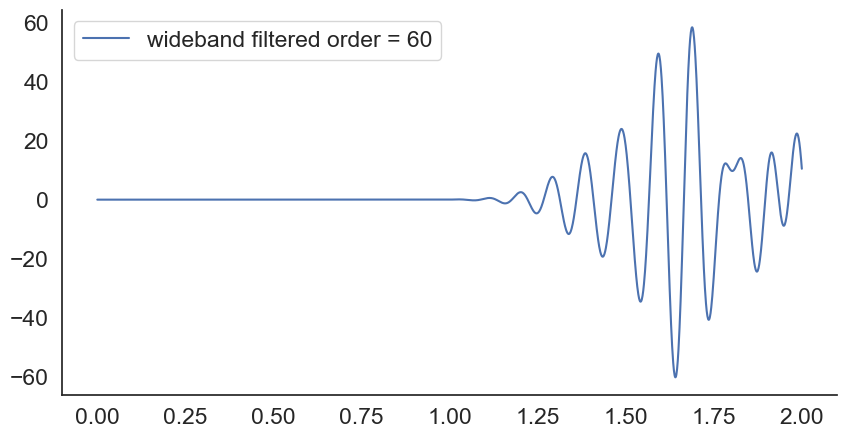

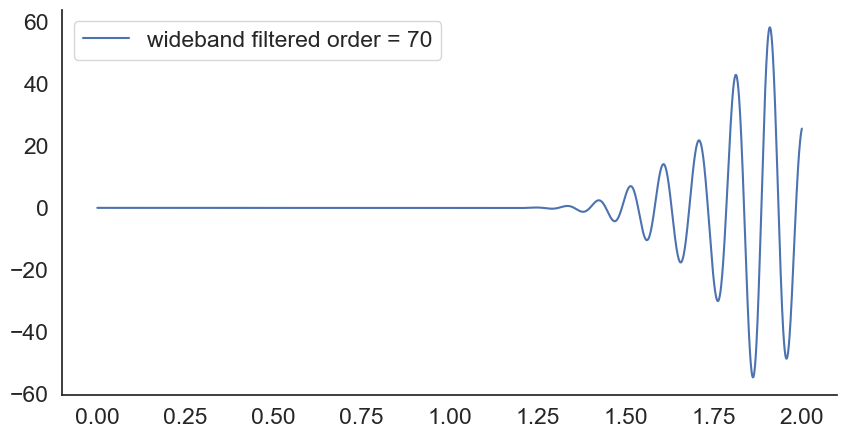

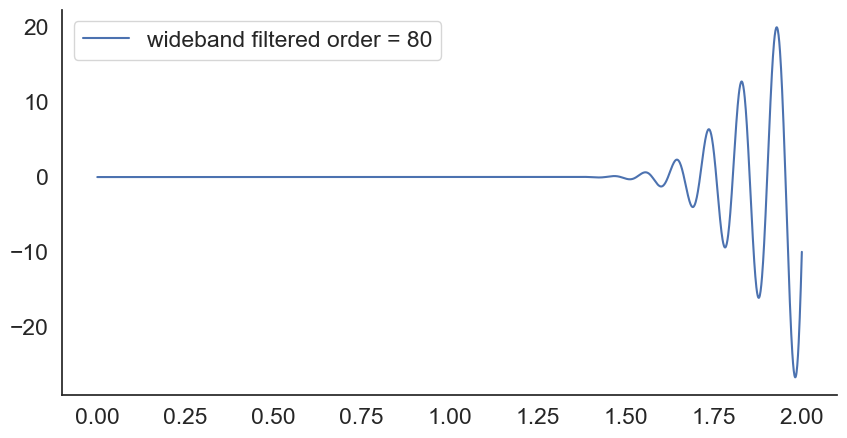

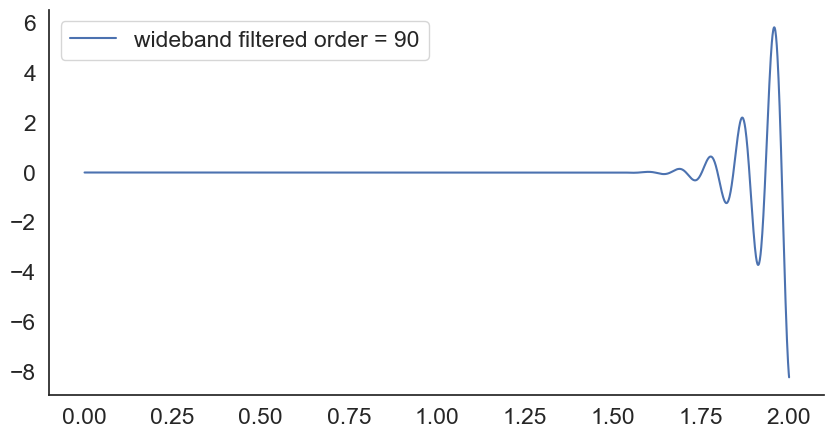

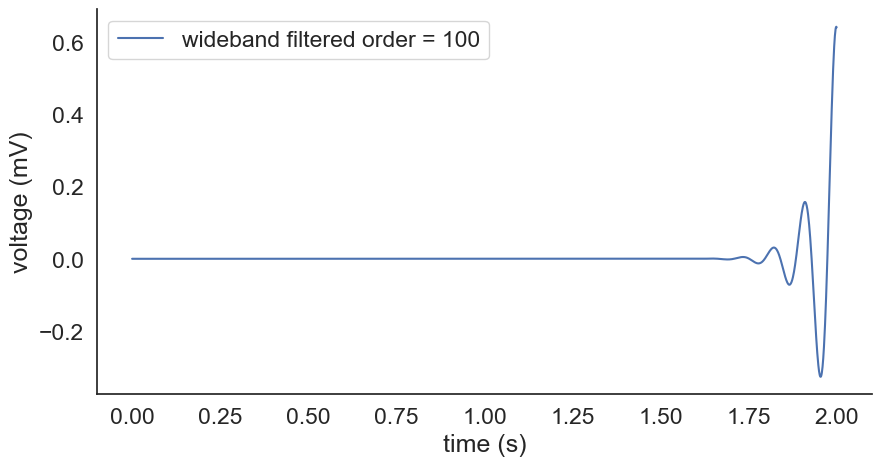

In [6]:
from scipy.signal import butter
from scipy.signal import sosfilt

# filter_order = 10 #the higher the order, the sharper the filter frequency response, 
                 #but with more computations and potental numerical instability
low_f = f_theta_central- width_theta_central
high_f = f_theta_central + width_theta_central

filter_orders = np.arange(0,101,10)

for filter_order in filter_orders:
    #define filter object
    filter = butter(filter_order,[low_f,high_f],
                    btype='band', 
                    output='sos', 
                    fs=sampling_rate)
                    
    #apply filter to lfp       
    wideband_lfp = sosfilt(filter, lfp)



    plt.figure(figsize=(10,5))
    plt.plot(np.linspace(0,2,2000),wideband_lfp[:2000],label = f'wideband filtered order = {filter_order}')
    #plt.plot(np.linspace(0,2,2000),lfp[:2000],label='raw signal')
    plt.legend()


plt.xlabel('time (s)')
plt.ylabel('voltage (mV)')


Increasing filter order has a smoothening effect on the signal. In addition to this the filter routine needs more datapoints before making an estimate and therefore seemingly shifts the function to later points in time.

## Exercise 2: wavelet transform with real wavelets
---
In this exercises you will explore the difference between real and complex wavelets in the continous wavelet transform.
- Import the data form `data/moving_lfp.pickle`
- Select a period of a few seconds of the signal and compute the spectrogram. 
  Try the wavelet transform with wavelet `mexh` (mexican hat),`gaus` (gaussian) and `morl` (morlet). These are all real wavelets.
- What differences do you see with respect to the spectrum computed with the complex Morlet tranform ? Comment on why do you think this might be the case.

In [7]:
from scipy import signal
from pywt import scale2frequency
from pywt import cwt
from pywt import wavelist

wavelist()  ## This function outputs the correct names for the wavelets: I chose gaus1, morl and mexh

['bior1.1',
 'bior1.3',
 'bior1.5',
 'bior2.2',
 'bior2.4',
 'bior2.6',
 'bior2.8',
 'bior3.1',
 'bior3.3',
 'bior3.5',
 'bior3.7',
 'bior3.9',
 'bior4.4',
 'bior5.5',
 'bior6.8',
 'cgau1',
 'cgau2',
 'cgau3',
 'cgau4',
 'cgau5',
 'cgau6',
 'cgau7',
 'cgau8',
 'cmor',
 'coif1',
 'coif2',
 'coif3',
 'coif4',
 'coif5',
 'coif6',
 'coif7',
 'coif8',
 'coif9',
 'coif10',
 'coif11',
 'coif12',
 'coif13',
 'coif14',
 'coif15',
 'coif16',
 'coif17',
 'db1',
 'db2',
 'db3',
 'db4',
 'db5',
 'db6',
 'db7',
 'db8',
 'db9',
 'db10',
 'db11',
 'db12',
 'db13',
 'db14',
 'db15',
 'db16',
 'db17',
 'db18',
 'db19',
 'db20',
 'db21',
 'db22',
 'db23',
 'db24',
 'db25',
 'db26',
 'db27',
 'db28',
 'db29',
 'db30',
 'db31',
 'db32',
 'db33',
 'db34',
 'db35',
 'db36',
 'db37',
 'db38',
 'dmey',
 'fbsp',
 'gaus1',
 'gaus2',
 'gaus3',
 'gaus4',
 'gaus5',
 'gaus6',
 'gaus7',
 'gaus8',
 'haar',
 'mexh',
 'morl',
 'rbio1.1',
 'rbio1.3',
 'rbio1.5',
 'rbio2.2',
 'rbio2.4',
 'rbio2.6',
 'rbio2.8',
 'rbio3.1',

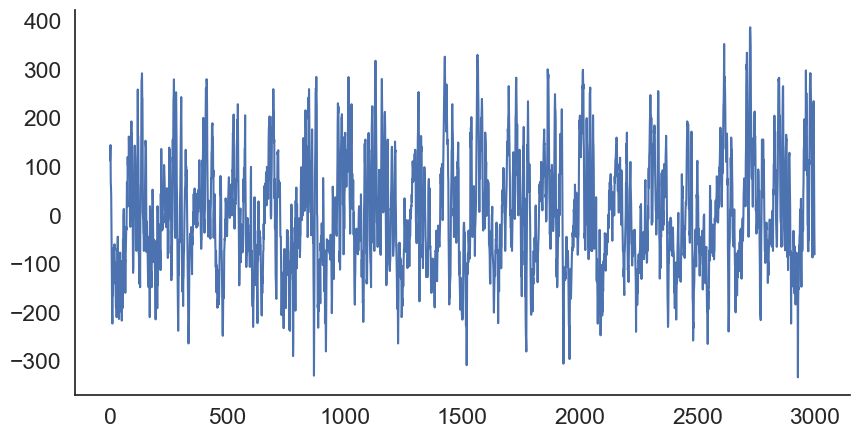

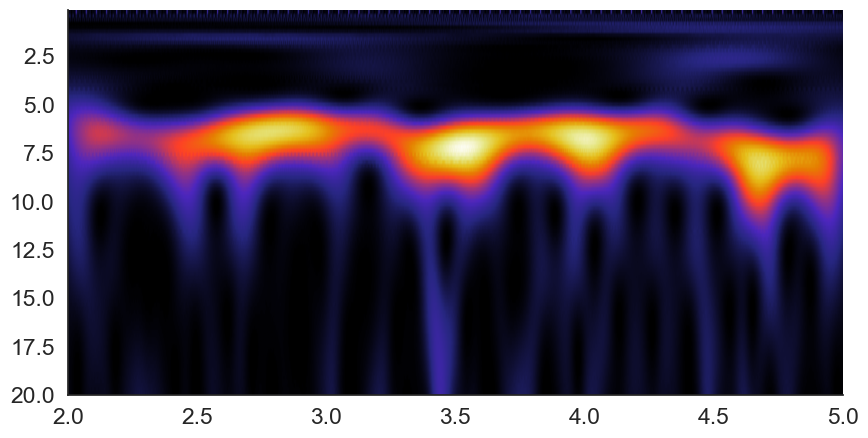

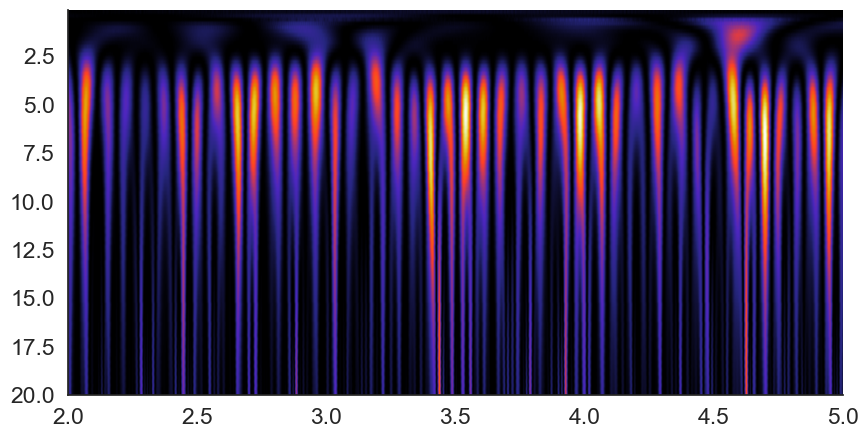

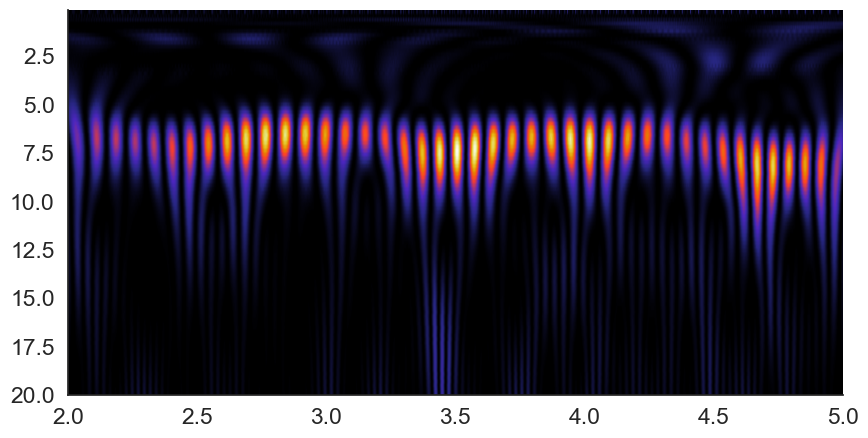

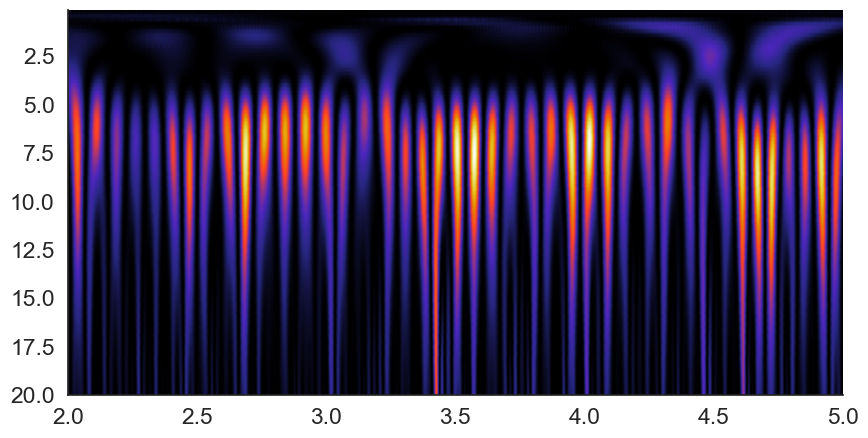

In [8]:
## Lesson code already had everything necessary for selection of a snippet of the signal, I just altered it such that it now takes a different portion of it
start = 2 #in seconds
end = 5 # in seconds


sig = lfp[int(start*sampling_rate):int(end*sampling_rate)]
sig = sig - np.mean(sig) # get rid of 0 frequency component

plt.figure(figsize=(10,5))
plt.plot(sig)



frequencies =  np.linspace(0.1,20,100)/sampling_rate

#spectrogram with complex morlet transform
frequencies =  np.linspace(0.1,20,100)/sampling_rate
wavelet = 'cmor1.0-1.0'
scales = scale2frequency(wavelet, frequencies)
cwtmatr, _ = cwt(sig, wavelet=wavelet, scales=scales,
                  sampling_period=1.0/sampling_rate)
plt.figure(figsize=(10,5))
plt.imshow(abs(cwtmatr)**2, extent=[start,end,frequencies[-1]*sampling_rate,
                         frequencies[0]*sampling_rate], aspect='auto', cmap='CMRmap')

#spectrogram with Gauss transform
wavelet = 'gaus1'
scales = scale2frequency(wavelet, frequencies)
cwtmatr, _ = cwt(sig, wavelet=wavelet, scales=scales,
                  sampling_period=1.0/sampling_rate)
plt.figure(figsize=(10,5))
plt.imshow(abs(cwtmatr)**2, extent=[start,end,frequencies[-1]*sampling_rate,
                         frequencies[0]*sampling_rate], aspect='auto', cmap='CMRmap')

#spectrogram with Gauss transform
wavelet = 'morl'
scales = scale2frequency(wavelet, frequencies)
cwtmatr, _ = cwt(sig, wavelet=wavelet, scales=scales,
                  sampling_period=1.0/sampling_rate)
plt.figure(figsize=(10,5))
plt.imshow(abs(cwtmatr)**2, extent=[start,end,frequencies[-1]*sampling_rate,
                         frequencies[0]*sampling_rate], aspect='auto', cmap='CMRmap')

#spectrogram with Gauss transform
wavelet = 'mexh'
scales = scale2frequency(wavelet, frequencies)
cwtmatr, _ = cwt(sig, wavelet=wavelet, scales=scales,
                  sampling_period=1.0/sampling_rate)
plt.figure(figsize=(10,5))
plt.imshow(abs(cwtmatr)**2, extent=[start,end,frequencies[-1]*sampling_rate,
                         frequencies[0]*sampling_rate], aspect='auto', cmap='CMRmap')


The difference with respect to the complex morlet transform is mainly visible in the time resolution, where the complex morlet requires you to set the central frequency and Bandwith in the string that designates the name of the wavelet type. Most likely, the default standard routine for the other wavelet types has a bandwidth that is better adjusted to the theta band than the 1.0-1.0 setting that was now used for the complex morlet transform.

## Exercise 3: REM sleep detection
---
Mammalian sleep is organized in different phases. [Rapid Eye Movement (REM) sleep](https://en.wikipedia.org/wiki/Rapid_eye_movement_sleep) is a well studied phase, with clear markers that make it detectable from LFP data. One of the most used marker is the ratio (or difference) between the oscillatory power in the theta and delta bands in the hippocampus. During REM sleep, the former dominates, in a pattern that resembles active behaviour.  
In this exercise we will use the tools we learned about to detect and inspect the REM and non-REM (nREM) phases of sleep in data recorded from the hippocampus of a sleeping mouse.

- Import the data form `data/sleep_lfp.pickle`
- Compute the instantaneous power in the theta (6-10 Hz) and delta (2-4 Hz) frequency bands, for the whole signal.
- z-score the two power signals (subtract the mean and divide by the standard deviation, you can use `scipy.stats.zscore()`)
- Compute and plot the power difference (`theta_power - delta_power`) for the sleep session.
- Compute the REM (power difference $>0.2$) and nREM (power diffewrence $<0.2$) sleep periods.
- Plot examples of REM vs nREM lfp signals (wideband filtered betw. 1 and 200 Hz to get rid of some of the noise).
- Explore how changing the threshold affects the amount of REM sleep detected.

In [9]:
with open('data/sleep_lfp.pickle', 'rb') as handle:
    lfp_data = pickle.load(handle)

sleep_lfp = lfp_data['lfp']
sampling_rate = lfp_data['sampling_rate']
print(f'Loaded {len(sleep_lfp)/sampling_rate} seconds of LFP, sampled at {sampling_rate} Hz')
len(sleep_lfp)

Loaded 1816.576 seconds of LFP, sampled at 1000.0 Hz


1816576

In [10]:
def compute_power(signal,sampling_rate,low_f=6,high_f=10):
    '''Takes lfp signal and sampling rate, returns instantaneous power in the specified band 
    (default is theta band 6-10 Hz)'''
    signal = signal - np.mean(signal) # get rid of 0 frequency component

    frequencies =  np.linspace(low_f,high_f,50)/sampling_rate
    wavelet = 'cmor2.0-1.0'                                     # Increased bandwith to improve frequency resolution for low frequencies 
    scales = scale2frequency(wavelet, frequencies)
    cwtmatr, _ = cwt(signal, wavelet=wavelet, scales=scales,
                    sampling_period=1.0/sampling_rate)


    power = np.mean(abs(cwtmatr)**2,axis=0)

    return power

In [11]:
theta_power = compute_power(sleep_lfp, sampling_rate)
delta_power = compute_power(sleep_lfp, sampling_rate, 2, 4)

In [12]:
from scipy.stats import zscore

z_theta = zscore(theta_power)
z_delta = zscore(delta_power)
print(z_theta, z_delta)
power_difference = theta_power - delta_power
z_power_diff = z_theta - z_delta

[-0.26802881 -0.2666576  -0.26516167 ... -0.11533139 -0.11902423
 -0.12231361] [-0.27605916 -0.27605548 -0.27606977 ... -0.27333596 -0.27342761
 -0.27339647]


Text(0.5, 0, 'time (s)')

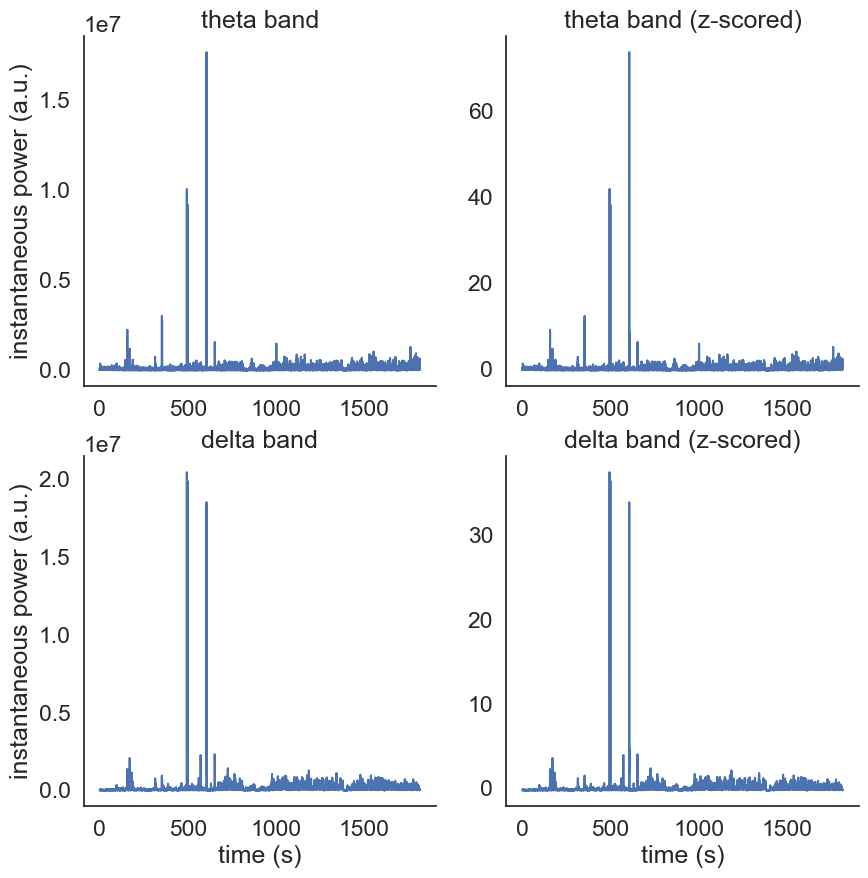

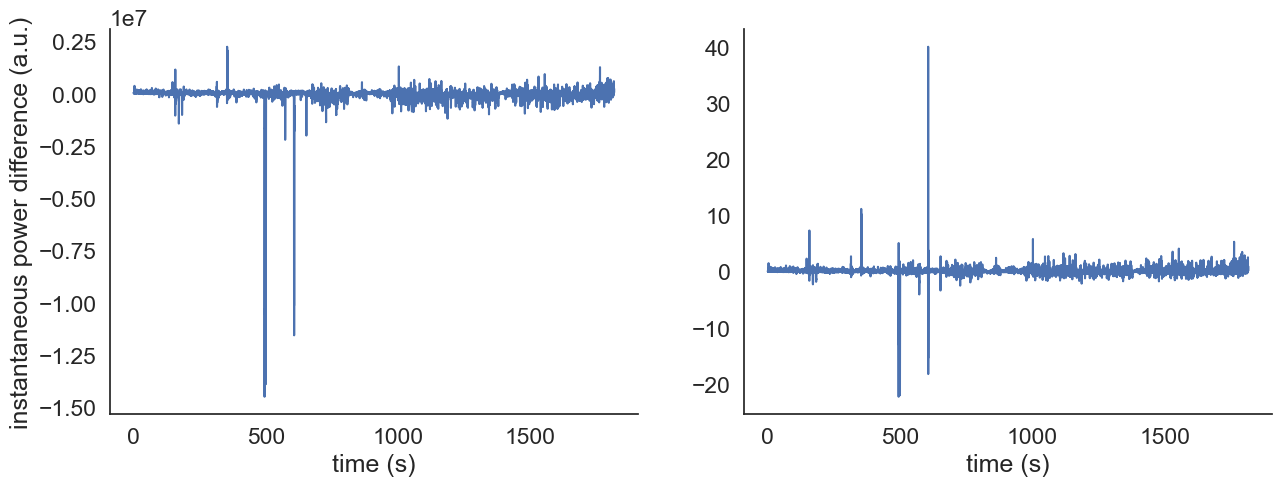

In [13]:
t = np. linspace(0, len(sleep_lfp)/sampling_rate, len(sleep_lfp))

plt.figure(figsize= (10,10))
plt.subplot(2,2,1)
plt.plot(t, theta_power)
plt.title("theta band")
plt.ylabel("instantaneous power (a.u.)")
plt.subplot(2,2,2)
plt.plot(t, z_theta)
plt.title("theta band (z-scored)")
plt.subplot(2,2,3)
plt.plot(t, delta_power)
plt.title("delta band")
plt.xlabel("time (s)")
plt.ylabel("instantaneous power (a.u.)")
plt.subplot(2,2,4)
plt.plot(t, z_delta)
plt.title("delta band (z-scored)")
plt.xlabel("time (s)")


plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(t , power_difference)
plt.xlabel("time (s)")
plt.ylabel("instantaneous power difference (a.u.)")
plt.subplot(1,2,2)
plt.plot(t , z_power_diff)
plt.xlabel("time (s)")

In [14]:
def REM_idx(REM_mask):
    '''
    Takes logical REM mask and returns a list of arrays. Each array correspond to a REM cycle
    and contains its time idxs (relative to the provided REM mask)
    '''
    REM_starts = []
    REM_ends = []
    for i in range(1, len(REM_mask)):
        if REM_mask[i-1] == 0 and REM_mask[i] == 1:
            REM_starts.append(i)
        if REM_mask[i-1] == 1 and REM_mask[i] == 0:
            REM_ends.append(i)

    # handle edge cases
    if len(REM_ends) > len(REM_starts):
        REM_starts = [0]+REM_starts  # if session starts with a cycle

    if len(REM_ends) < len(REM_starts):
        REM_ends.append(len(REM_mask))  # if session ends with a cycle

    REMs = [np.arange(REM_starts[i], REM_ends[i])
               for i in range(len(REM_starts))]

    return REMs


def clean_REMs(REM_cycles,lfp,REM_len=2.0,amplitude_REM=10):
    '''takes list of REM cycles and corresponding signal, returns list of REM cycles cleaned of REM cycles that are shorter than specified 
    duration threshold or with differences larger than specified difference threshold (usually artifacts)'''
    clean_REM_cycles = [r for r in REM_cycles if (len(r)>REM_len and \
                    max(lfp[r])< amplitude_REM and min(lfp[r])>-amplitude_REM)] 
    return clean_REM_cycles

In [15]:
threshold = 0.2

REM_mask = np.where(z_power_diff > threshold, 1, 0)
# idx_nrem = np.where(power_difference <= threshold, True, False)


REM_cycles = REM_idx(REM_mask)

# Clean_REM_cycles = clean_REMs(REM_cycles, sleep_lfp, REM_len=1) # Should choose difference threshold based on z-score

print(f'detected {len(REM_cycles)} REM cycles')   # This is slightly misleading since if the threshold is set to low than cycle durations will be longer resulting in less cycles overall but longer periods of time spent in REM, the next lines illustrates this
cycle_durations = []
for REM_cycle in REM_cycles: 
    cycle_durations.append(len(REM_cycle))

print(f'For a threshold of {threshold} the total time spent in REM sleep was: {int(np.sum(cycle_durations))/sampling_rate} seconds. With individual cycles lasting {np.mean(cycle_durations)/sampling_rate} seconds on average')
REM_cycles

detected 1442 REM cycles
For a threshold of 0.2 the total time spent in REM sleep was: 394.791 seconds. With individual cycles lasting 0.27378016643550623 seconds on average


[array([1203, 1204, 1205, 1206, 1207, 1208, 1209, 1210, 1211, 1212, 1213,
        1214, 1215, 1216, 1217, 1218, 1219, 1220, 1221, 1222, 1223, 1224,
        1225, 1226, 1227, 1228, 1229, 1230, 1231, 1232, 1233, 1234, 1235,
        1236, 1237, 1238, 1239, 1240, 1241, 1242, 1243, 1244, 1245, 1246,
        1247, 1248, 1249, 1250, 1251, 1252, 1253, 1254, 1255, 1256, 1257,
        1258, 1259, 1260, 1261, 1262, 1263, 1264, 1265, 1266, 1267, 1268,
        1269, 1270, 1271, 1272, 1273, 1274, 1275, 1276, 1277, 1278, 1279,
        1280, 1281, 1282, 1283, 1284]),
 array([1563]),
 array([1565, 1566, 1567, 1568, 1569, 1570, 1571, 1572, 1573, 1574, 1575,
        1576, 1577, 1578, 1579, 1580, 1581, 1582, 1583, 1584, 1585, 1586,
        1587, 1588, 1589, 1590, 1591, 1592, 1593, 1594, 1595, 1596, 1597,
        1598, 1599, 1600, 1601, 1602, 1603, 1604, 1605, 1606, 1607, 1608,
        1609, 1610, 1611, 1612, 1613, 1614, 1615, 1616, 1617, 1618, 1619,
        1620, 1621, 1622, 1623, 1624, 1625, 1626, 1627, 

In [16]:
filter_order = 5 
low_f = 1
high_f = 200

#define filter object
filter = butter(filter_order,[low_f,high_f],
                btype='band', 
                output='sos', 
                fs=sampling_rate)
                
#apply filter to lfp       
wideband_sleep_lfp = sosfilt(filter, sleep_lfp)

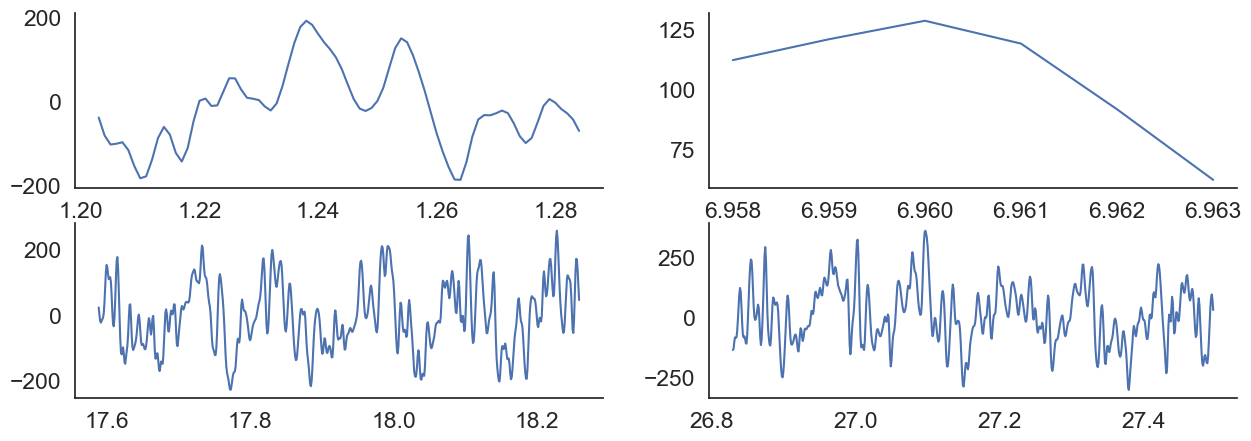

In [17]:
REM_example_1 = wideband_sleep_lfp[REM_cycles[0]]
REM_example_2 = wideband_sleep_lfp[REM_cycles[10]]
REM_example_3 = wideband_sleep_lfp[REM_cycles[25]]
REM_example_4 = wideband_sleep_lfp[REM_cycles[38]]



plt.figure(figsize=(15,5))
plt.subplot(2,2,1)
plt.plot(t[REM_cycles[0]], REM_example_1)
plt.subplot(2,2,2)
plt.plot(t[REM_cycles[10]], REM_example_2)
plt.subplot(2,2,3)
plt.plot(t[REM_cycles[25]], REM_example_3)
plt.subplot(2,2,4)
plt.plot(t[REM_cycles[38]], REM_example_4)

In [18]:
z_power_diff = zscore(power_difference)
threshold = 0.5

REM_mask = np.where(z_power_diff > threshold, 1, 0)
# idx_nrem = np.where(power_difference <= threshold, True, False)


REM_cycles = REM_idx(REM_mask)

#Clean_REM_cycles = clean_REMs(REM_cycles,sleep_lfp,REM_len=2) # Should choose difference threshold based on z-score

print(f'detected {len(REM_cycles)} REM cycles')

cycle_durations = []
for REM_cycle in REM_cycles: 
    cycle_durations.append(len(REM_cycle))

print(f'For a threshold of {threshold} the total time spent in REM sleep was: {int(np.sum(cycle_durations))/sampling_rate}. With individual cycles lasting {np.mean(cycle_durations)/sampling_rate} seconds on average')


detected 474 REM cycles
For a threshold of 0.5 the total time spent in REM sleep was: 80.656. With individual cycles lasting 0.17016033755274262 seconds on average


In [19]:
z_power_diff = zscore(power_difference)
threshold = 0.9

REM_mask = np.where(z_power_diff > threshold, 1, 0)
# idx_nrem = np.where(power_difference <= threshold, True, False)


REM_cycles = REM_idx(REM_mask)

#Clean_REM_cycles = clean_REMs(REM_cycles,sleep_lfp,REM_len=2) # Should choose difference threshold based on z-score

print(f'detected {len(REM_cycles)} REM cycles')

cycle_durations = []
for REM_cycle in REM_cycles: 
    cycle_durations.append(len(REM_cycle))

print(f'For a threshold of {threshold} the total time spent in REM sleep was: {int(np.sum(cycle_durations))/sampling_rate}. With individual cycles lasting {np.mean(cycle_durations)/sampling_rate} seconds on average')


detected 113 REM cycles
For a threshold of 0.9 the total time spent in REM sleep was: 18.119. With individual cycles lasting 0.16034513274336282 seconds on average


Raising the threshold has the predictable effect of decreasing the number of detected cycles and shortening the average cycle length 